<a href="https://colab.research.google.com/github/datadigger01/AppStatMat/blob/main/FlightDelay_NaiveBayes_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 항공기 지연데이터

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/datadigger01/AppStatMat/main/Data/FlightDelays.csv"
df = pd.read_csv(url)
display(df.head())

,CRS_DEP_TIME,CARRIER,DEP_TIME,DEST,DISTANCE,FL_DATE,FL_NUM,ORIGIN,Weather,DAY_WEEK,DAY_OF_MONTH,TAIL_NUM,Flight Status
0,1455,OH,1455,JFK,184,01/01/2004,5935,BWI,0,4,1,N940CA,ontime
1,1640,DH,1640,JFK,213,01/01/2004,6155,DCA,0,4,1,N405FJ,ontime
2,1245,DH,1245,LGA,229,01/01/2004,7208,IAD,0,4,1,N695BR,ontime
3,1715,DH,1709,LGA,229,01/01/2004,7215,IAD,0,4,1,N662BR,ontime
4,1039,DH,1035,LGA,229,01/01/2004,7792,IAD,0,4,1,N698BR,ontime


In [2]:
print(df.info())
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2201 entries, 0 to 2200
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CRS_DEP_TIME   2201 non-null   int64 
 1   CARRIER        2201 non-null   object
 2   DEP_TIME       2201 non-null   int64 
 3   DEST           2201 non-null   object
 4   DISTANCE       2201 non-null   int64 
 5   FL_DATE        2201 non-null   object
 6   FL_NUM         2201 non-null   int64 
 7   ORIGIN         2201 non-null   object
 8   Weather        2201 non-null   int64 
 9   DAY_WEEK       2201 non-null   int64 
 10  DAY_OF_MONTH   2201 non-null   int64 
 11  TAIL_NUM       2201 non-null   object
 12  Flight Status  2201 non-null   object
dtypes: int64(7), object(6)
memory usage: 223.7+ KB
None


,CRS_DEP_TIME,CARRIER,DEP_TIME,DEST,DISTANCE,FL_DATE,FL_NUM,ORIGIN,Weather,DAY_WEEK,DAY_OF_MONTH,TAIL_NUM,Flight Status
0,1455,OH,1455,JFK,184,01/01/2004,5935,BWI,0,4,1,N940CA,ontime
1,1640,DH,1640,JFK,213,01/01/2004,6155,DCA,0,4,1,N405FJ,ontime
2,1245,DH,1245,LGA,229,01/01/2004,7208,IAD,0,4,1,N695BR,ontime
3,1715,DH,1709,LGA,229,01/01/2004,7215,IAD,0,4,1,N662BR,ontime
4,1039,DH,1035,LGA,229,01/01/2004,7792,IAD,0,4,1,N698BR,ontime
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2196,645,RU,644,EWR,199,1/31/2004,2761,DCA,0,6,31,N15555,ontime
2197,1700,RU,1653,EWR,213,1/31/2004,2497,IAD,0,6,31,N16976,ontime
2198,1600,RU,1558,EWR,199,1/31/2004,2361,DCA,0,6,31,N14902,ontime
2199,1359,RU,1403,EWR,199,1/31/2004,2216,DCA,0,6,31,N16961,ontime


## 1. 컬럼명 타입 변환
- FL_DATE 컬럼은 date 타입으로 변환

In [3]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

display(df.info())
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2201 entries, 0 to 2200
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CRS_DEP_TIME   2201 non-null   int64         
 1   CARRIER        2201 non-null   object        
 2   DEP_TIME       2201 non-null   int64         
 3   DEST           2201 non-null   object        
 4   DISTANCE       2201 non-null   int64         
 5   FL_DATE        2201 non-null   datetime64[ns]
 6   FL_NUM         2201 non-null   int64         
 7   ORIGIN         2201 non-null   object        
 8   Weather        2201 non-null   int64         
 9   DAY_WEEK       2201 non-null   int64         
 10  DAY_OF_MONTH   2201 non-null   int64         
 11  TAIL_NUM       2201 non-null   object        
 12  Flight Status  2201 non-null   object        
dtypes: datetime64[ns](1), int64(7), object(5)
memory usage: 223.7+ KB


None

,CRS_DEP_TIME,CARRIER,DEP_TIME,DEST,DISTANCE,FL_DATE,FL_NUM,ORIGIN,Weather,DAY_WEEK,DAY_OF_MONTH,TAIL_NUM,Flight Status
0,1455,OH,1455,JFK,184,2004-01-01,5935,BWI,0,4,1,N940CA,ontime
1,1640,DH,1640,JFK,213,2004-01-01,6155,DCA,0,4,1,N405FJ,ontime
2,1245,DH,1245,LGA,229,2004-01-01,7208,IAD,0,4,1,N695BR,ontime
3,1715,DH,1709,LGA,229,2004-01-01,7215,IAD,0,4,1,N662BR,ontime
4,1039,DH,1035,LGA,229,2004-01-01,7792,IAD,0,4,1,N698BR,ontime
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2196,645,RU,644,EWR,199,2004-01-31,2761,DCA,0,6,31,N15555,ontime
2197,1700,RU,1653,EWR,213,2004-01-31,2497,IAD,0,6,31,N16976,ontime
2198,1600,RU,1558,EWR,199,2004-01-31,2361,DCA,0,6,31,N14902,ontime
2199,1359,RU,1403,EWR,199,2004-01-31,2216,DCA,0,6,31,N16961,ontime


## 2. Target 컬럼 생성
- 컬럼명 'Fight Status'의 값이 'ontime'이면 숫자 0 나머지(지연) 1으로 생성하여 delay_yn 컬럼명으로 새로 생성

In [4]:
df['delay_yn'] = (df['Flight Status'] != 'ontime').astype(int)
display(df.head())

,CRS_DEP_TIME,CARRIER,DEP_TIME,DEST,DISTANCE,FL_DATE,FL_NUM,ORIGIN,Weather,DAY_WEEK,DAY_OF_MONTH,TAIL_NUM,Flight Status,delay_yn
0,1455,OH,1455,JFK,184,2004-01-01,5935,BWI,0,4,1,N940CA,ontime,0
1,1640,DH,1640,JFK,213,2004-01-01,6155,DCA,0,4,1,N405FJ,ontime,0
2,1245,DH,1245,LGA,229,2004-01-01,7208,IAD,0,4,1,N695BR,ontime,0
3,1715,DH,1709,LGA,229,2004-01-01,7215,IAD,0,4,1,N662BR,ontime,0
4,1039,DH,1035,LGA,229,2004-01-01,7792,IAD,0,4,1,N698BR,ontime,0


In [ ]:
df.columns

Index(['CRS_DEP_TIME', 'CARRIER', 'DEP_TIME', 'DEST', 'DISTANCE', 'FL_DATE',
       'FL_NUM', 'ORIGIN', 'Weather', 'DAY_WEEK', 'DAY_OF_MONTH', 'TAIL_NUM',
       'Flight Status', 'delay_yn'],
      dtype='object')

## 3. 결측값 확인 및 대체

In [5]:
missing_values_count = df.isnull().sum()
display(missing_values_count)

,0
CRS_DEP_TIME,0
CARRIER,0
DEP_TIME,0
DEST,0
DISTANCE,0
FL_DATE,0
FL_NUM,0
ORIGIN,0
Weather,0
DAY_WEEK,0


## 4.새로운 변수 파생
- CRS_DEP_TIME을 100으로 나누어 반올림(round) 처리 : 출발예정시간으로 오전 6:00 부터 10:00 사이를 18개의 그룹 등간격

- Fl_DATE 컬럼으로부터 월 추출

In [6]:
df['CRS_DEP_TIME_G'] = round(df['CRS_DEP_TIME'] / 100).astype(int)

#df['DEP_MONTH'] = df['FL_DATE'].dt.month
#print(df.info())
display(df)

,CRS_DEP_TIME,CARRIER,DEP_TIME,DEST,DISTANCE,FL_DATE,FL_NUM,ORIGIN,Weather,DAY_WEEK,DAY_OF_MONTH,TAIL_NUM,Flight Status,delay_yn,CRS_DEP_TIME_G
0,1455,OH,1455,JFK,184,2004-01-01,5935,BWI,0,4,1,N940CA,ontime,0,15
1,1640,DH,1640,JFK,213,2004-01-01,6155,DCA,0,4,1,N405FJ,ontime,0,16
2,1245,DH,1245,LGA,229,2004-01-01,7208,IAD,0,4,1,N695BR,ontime,0,12
3,1715,DH,1709,LGA,229,2004-01-01,7215,IAD,0,4,1,N662BR,ontime,0,17
4,1039,DH,1035,LGA,229,2004-01-01,7792,IAD,0,4,1,N698BR,ontime,0,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2196,645,RU,644,EWR,199,2004-01-31,2761,DCA,0,6,31,N15555,ontime,0,6
2197,1700,RU,1653,EWR,213,2004-01-31,2497,IAD,0,6,31,N16976,ontime,0,17
2198,1600,RU,1558,EWR,199,2004-01-31,2361,DCA,0,6,31,N14902,ontime,0,16
2199,1359,RU,1403,EWR,199,2004-01-31,2216,DCA,0,6,31,N16961,ontime,0,14


In [7]:
# 그룹별 발생빈도 확인
df['CRS_DEP_TIME_G'].value_counts()

,count
CRS_DEP_TIME_G,
15,292
17,241
16,178
8,164
12,142
21,137
7,133
13,132
6,126


In [8]:
df.to_csv('FlightDelays_new.csv', index=False)

In [47]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load data
#df = pd.read_csv("FlightDelays_new.csv")

# 2. Define features and target
feature_cols = [
    "CARRIER",
    "DEST",
    "DISTANCE",
    "ORIGIN",
    "Weather",
    "DAY_WEEK",
    "DAY_OF_MONTH",
    "CRS_DEP_TIME_G",
    "DEP_TIME",
]
X = df[feature_cols]
y = df["delay_yn"]

# 3. Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=4212,
    stratify=y
)

# 4. Preprocessing: one-hot for categoricals, pass-through for numerics
categorical_features = ["CARRIER", "DEST", "ORIGIN"]
numeric_features = [
    "DISTANCE",
    "Weather",
    "DAY_WEEK",
    "DAY_OF_MONTH",
    "CRS_DEP_TIME_G",
    "DEP_TIME",
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

# 5. Naive Bayes model (GaussianNB)
nb_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", GaussianNB())
])

# 6. Train
nb_clf.fit(X_train, y_train)

# 7. Evaluate
y_pred = nb_clf.predict(X_test)

print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred)))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

# 8. Example: predicted delay probability for first 5 test samples
y_proba = nb_clf.predict_proba(X_test[:5])
print("\nPredicted probabilities (first 5 rows):")
print(y_proba)

Accuracy: 0.8231

Confusion matrix:
[[346   9]
 [ 69  17]]

Classification report:
              precision    recall  f1-score   support

           0     0.8337    0.9746    0.8987       355
           1     0.6538    0.1977    0.3036        86

    accuracy                         0.8231       441
   macro avg     0.7438    0.5862    0.6011       441
weighted avg     0.7987    0.8231    0.7826       441


Predicted probabilities (first 5 rows):
[[0.99999836 0.00000164]
 [0.96955645 0.03044355]
 [0.92923067 0.07076933]
 [0.97464256 0.02535744]
 [0.89542773 0.10457227]]


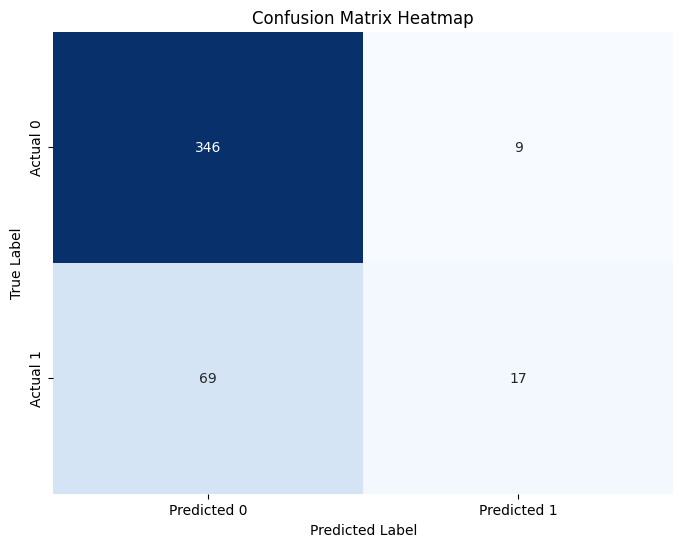

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix again using y_test and y_pred
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [49]:
from sklearn.metrics import confusion_matrix

# Assuming cm is already calculated from previous steps
# cm = confusion_matrix(y_test, y_pred)

# Extracting values from the confusion matrix
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

# Calculate Sensitivity (Recall)
sensitivity = TP / (TP + FN)

# Calculate Specificity
specificity = TN / (TN + FP)

# Calculate Precision
precision = TP / (TP + FP)

print(f"민감도 (Sensitivity): {sensitivity:.4f}")
print(f"특이도 (Specificity): {specificity:.4f}")
print(f"정밀도 (Precision): {precision:.4f}")

민감도 (Sensitivity): 0.1977
특이도 (Specificity): 0.9746
정밀도 (Precision): 0.6538


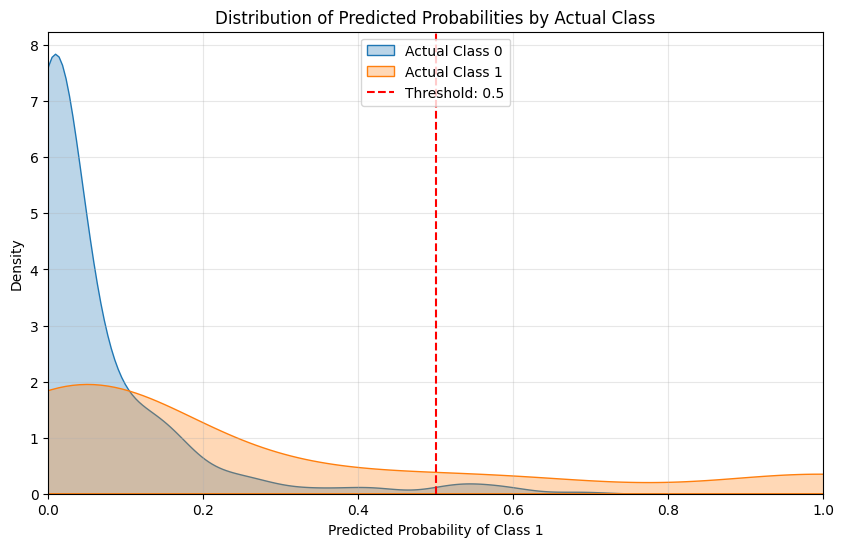

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 예측 확률 얻기 (Class 1에 대한 확률만 추출하는 것이 일반적입니다)
# y_pred_proba가 이미 (N, 2) 형태라고 가정합니다.
prob_class_1 = nb_clf.predict_proba(X_test)[:, 1]

# 데이터 타입 안정성을 위해 y_test를 numpy array로 변환 (Pandas Series일 경우 인덱스 충돌 방지)
y_test_np = np.array(y_test)

plt.figure(figsize=(10, 6))

# 2. 분포 그리기 (KDE Plot)
# 'shade=True'는 최신 버전에서 'fill=True'로 변경되었습니다.
# alpha 값을 조절하여 겹치는 부분이 잘 보이게 투명도를 설정합니다.
sns.kdeplot(prob_class_1[y_test_np == 0], label='Actual Class 0', fill=True, alpha=0.3)
sns.kdeplot(prob_class_1[y_test_np == 1], label='Actual Class 1', fill=True, alpha=0.3)

# 3. 임계값(Threshold) 선 그리기
threshold = 0.5
plt.axvline(x=threshold, color='red', linestyle='--', linewidth=1.5, label=f'Threshold: {threshold}')

# 4. 그래프 스타일링
plt.xlabel('Predicted Probability of Class 1')
plt.ylabel('Density')
plt.title('Distribution of Predicted Probabilities by Actual Class')
plt.xlim(0, 1) # 확률은 0과 1 사이이므로 범위를 고정
plt.legend(loc='upper center') # 범례 위치 조정
plt.grid(True, alpha=0.3) # 격자 추가로 가독성 향상

plt.show()

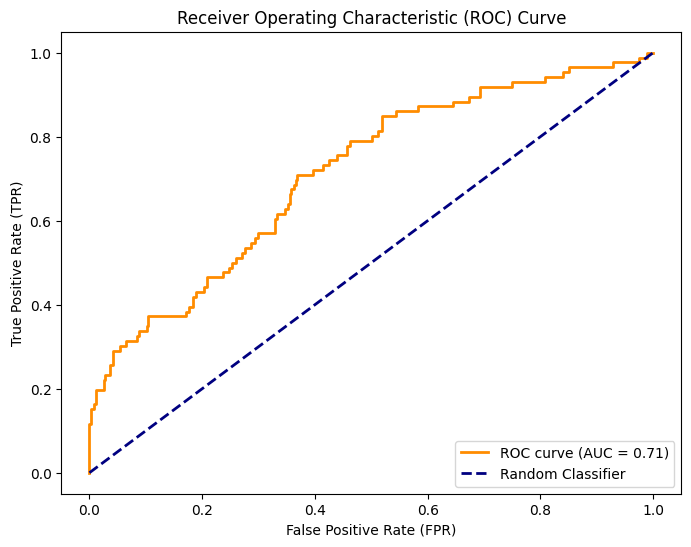

AUC Score: 0.7133


In [51]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (class 1)
y_pred_proba = nb_clf.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
#plt.grid(True)
plt.show()

print(f"AUC Score: {auc_score:.4f}")

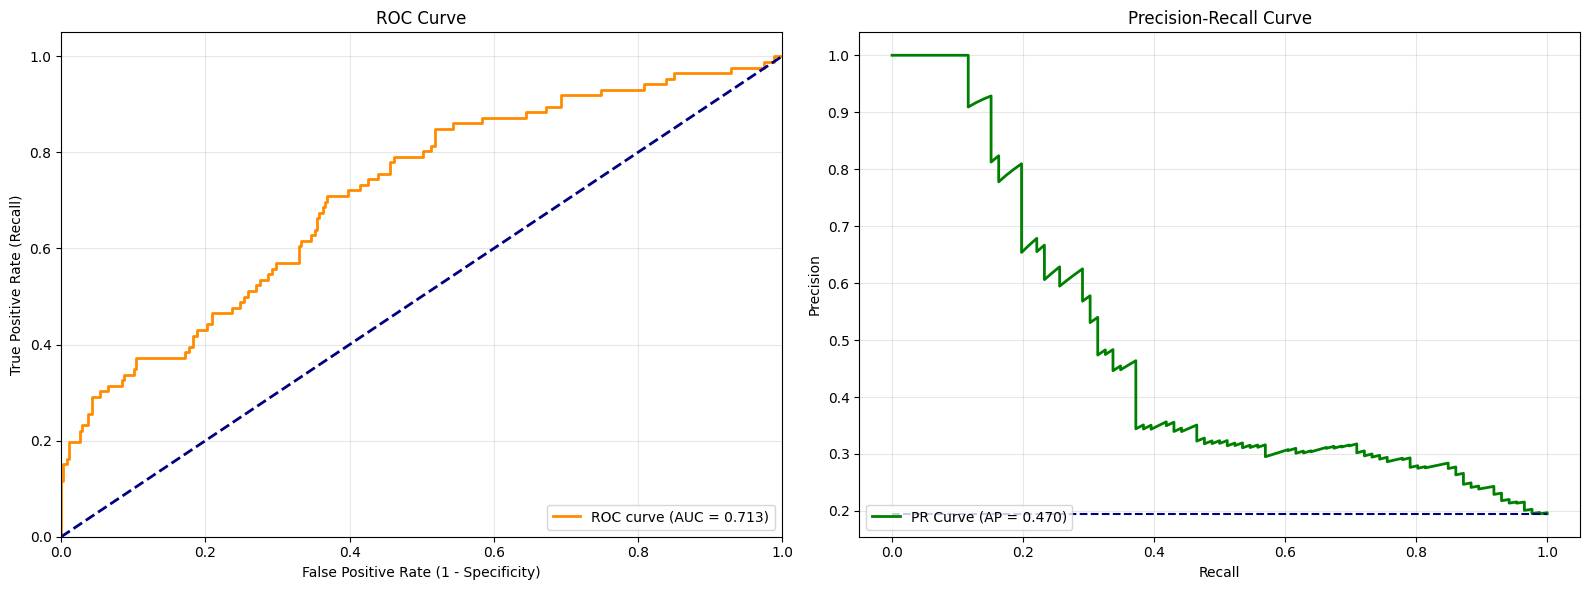

In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# 1. Class 1에 대한 예측 확률 추출
y_pred_proba_1 = nb_clf.predict_proba(X_test)[:, 1]

# 2. 그래프 그릴 공간 설정 (1행 2열)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- (1) ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_1)
roc_auc = auc(fpr, tpr) # AUC 면적 계산

ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 랜덤 추측선
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('False Positive Rate (1 - Specificity)')
ax[0].set_ylabel('True Positive Rate (Recall)')
ax[0].set_title('ROC Curve')
ax[0].legend(loc="lower right")
ax[0].grid(True, alpha=0.3)

# --- (2) Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_1)
ap_score = average_precision_score(y_test, y_pred_proba_1) # Average Precision 점수

ax[1].plot(recall, precision, color='green', lw=2, label=f'PR Curve (AP = {ap_score:.3f})')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall Curve')
ax[1].legend(loc="lower left")
ax[1].grid(True, alpha=0.3)
# 기준선 (No Skill) - 데이터의 불균형 정도에 따라 위치가 달라짐 (Positive 비율)
no_skill = len(y_test[y_test==1]) / len(y_test)
ax[1].plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill', color='navy')


plt.tight_layout()
plt.show()